# Lab 8: Implementation and Performance Evaluation of Categorical Naive Bayes Classifier

**Dataset:** Play Tennis (50 instances, 4 categorical features)

**Objective:** Build a complete classification pipeline that:
1. Preprocesses categorical data via encoding
2. Splits data into training and testing sets (80:20)
3. Trains and evaluates a **Categorical Naive Bayes** classifier
4. Performs single-sample inference with class probabilities
5. Compares Naive Bayes against **Decision Tree**, **Logistic Regression**, and **SVM**

---

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Preprocessing

### 2.1 Load the Dataset

In [2]:
df = pd.read_csv('PlayTennis.csv')

# Drop the serial number column - it carries no predictive information
if 'No' in df.columns:
    df = df.drop(columns=['No'])

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


**Interpretation:** The dataset contains 50 observations describing weather conditions
(`Outlook`, `Temperature`, `Humidity`, `Wind`) and the corresponding decision on whether tennis
was played (`Play Tennis`). All four input features and the target are categorical (nominal) variables.

In [3]:
print("Dataset Info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nClass distribution (target variable):")
print(df['Play Tennis'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Outlook      50 non-null     str  
 1   Temperature  50 non-null     str  
 2   Humidity     50 non-null     str  
 3   Wind         50 non-null     str  
 4   Play Tennis  50 non-null     str  
dtypes: str(5)
memory usage: 2.1 KB

Missing values per column:
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0
dtype: int64

Class distribution (target variable):
Play Tennis
Yes    34
No     16
Name: count, dtype: int64


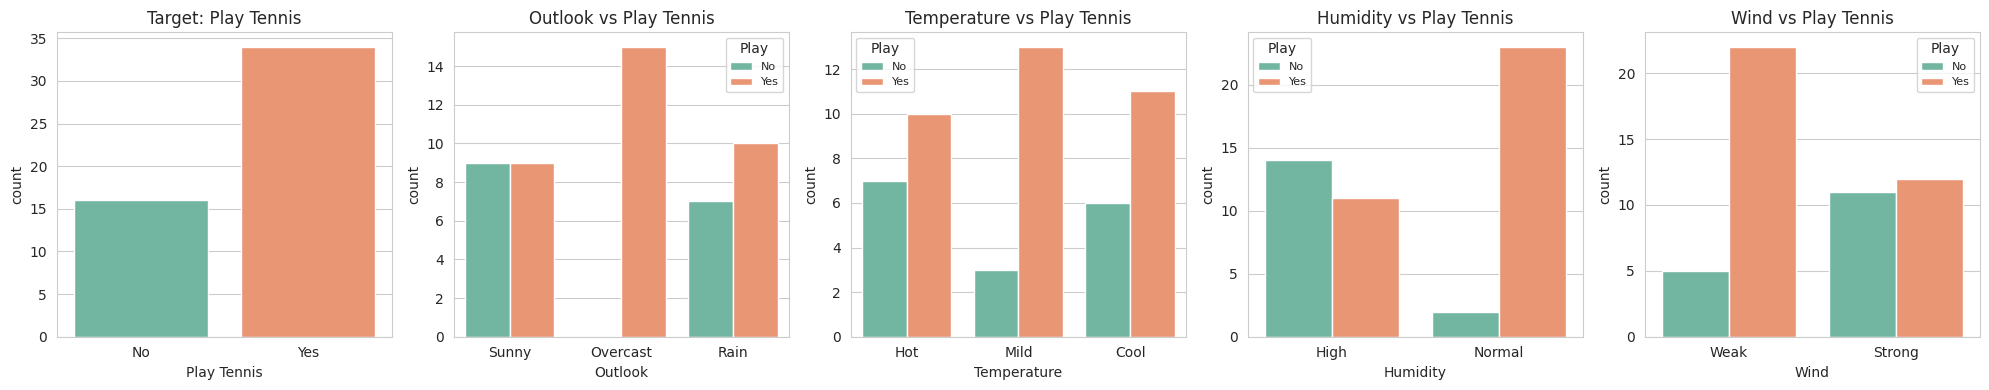

In [4]:
# Visualize class balance and feature distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

sns.countplot(x='Play Tennis', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target: Play Tennis')

for i, col in enumerate(['Outlook', 'Temperature', 'Humidity', 'Wind']):
    sns.countplot(x=col, hue='Play Tennis', data=df, ax=axes[i+1], palette='Set2')
    axes[i+1].set_title(f'{col} vs Play Tennis')
    axes[i+1].legend(title='Play', fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation:** The target is moderately imbalanced (34 "Yes" vs 16 "No" ≈ 68%/32%),
which is why the train-test split is **stratified** in Section 2.3, so both classes are
represented proportionally in the train and test sets. From the bar plots, `Overcast` outlook
almost always leads to "Yes", while `Sunny` + `High` humidity is associated with "No" — patterns
the classifiers below are expected to pick up on.

### 2.2 Separate Features and Target, and Encode Categorical Values

In [5]:
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
target_col = 'Play Tennis'

X_raw = df[feature_cols]
y_raw = df[target_col]

# --- Encode input features ---
# CategoricalNB (and the other sklearn estimators used for comparison) require numeric
# input, so we use OrdinalEncoder to map each category to an integer code per column.
# This is the appropriate encoding for CategoricalNB, which internally treats each
# encoded integer as a distinct category (NOT an ordinal magnitude).
ordinal_encoder = OrdinalEncoder(dtype=int)
X_encoded = ordinal_encoder.fit_transform(X_raw)
X = pd.DataFrame(X_encoded, columns=feature_cols)

# --- Encode target labels ---
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Feature encoding categories learned:")
for col, cats in zip(feature_cols, ordinal_encoder.categories_):
    print(f"  {col}: {list(cats)} -> {list(range(len(cats)))}")

print(f"\nTarget classes: {list(label_encoder.classes_)} -> {list(range(len(label_encoder.classes_)))}")

print("\nEncoded feature matrix (first 5 rows):")
X.head()

Feature encoding categories learned:
  Outlook: ['Overcast', 'Rain', 'Sunny'] -> [0, 1, 2]
  Temperature: ['Cool', 'Hot', 'Mild'] -> [0, 1, 2]
  Humidity: ['High', 'Normal'] -> [0, 1]
  Wind: ['Strong', 'Weak'] -> [0, 1]

Target classes: ['No', 'Yes'] -> [0, 1]

Encoded feature matrix (first 5 rows):


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


**Interpretation:** `OrdinalEncoder` was chosen over One-Hot Encoding because `CategoricalNB`
is explicitly designed to work with integer-encoded categorical features directly — it estimates a
separate categorical (multinoulli) distribution per feature per class, so one-hot expansion is
unnecessary and would only inflate dimensionality. The encoded integers carry **no ordinal
meaning**; they are simply category identifiers.

### 2.3 Dataset Partitioning (80:20 Train-Test Split)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserves the Yes/No class ratio in both splits
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size : {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nTesting class distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

Training set size: 40 samples
Testing set size : 10 samples

Training class distribution:
0    13
1    27
Name: count, dtype: int64

Testing class distribution:
0    3
1    7
Name: count, dtype: int64


**Interpretation:** With 50 total records, an 80:20 split yields 40 training and 10 testing
samples. `stratify=y` ensures the roughly 2:1 Yes:No ratio present in the full dataset is preserved
in both subsets, avoiding a test set that is accidentally skewed toward one class.

## 3. Naive Bayes Model Training & Evaluation

### 3.1 Train the Categorical Naive Bayes Model

In [7]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Categorical Naive Bayes model trained successfully.")
print(f"\nPredicted labels : {label_encoder.inverse_transform(y_pred_nb)}")
print(f"Actual labels    : {label_encoder.inverse_transform(y_test)}")

Categorical Naive Bayes model trained successfully.

Predicted labels : ['Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes']
Actual labels    : ['No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes']


### 3.2 Model Accuracy

In [8]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Categorical Naive Bayes Test Accuracy: {nb_accuracy:.4f}  ({nb_accuracy*100:.2f}%)")

Categorical Naive Bayes Test Accuracy: 0.9000  (90.00%)


### 3.3 Confusion Matrix

Confusion Matrix:
 [[2 1]
 [0 7]]


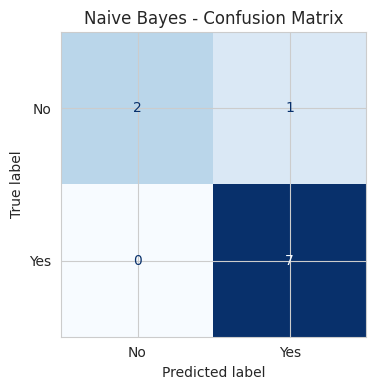

In [9]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm_nb)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Naive Bayes - Confusion Matrix')
plt.tight_layout()
plt.show()

### 3.4 Classification Report

In [10]:
print("Classification Report (Categorical Naive Bayes):\n")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

Classification Report (Categorical Naive Bayes):

              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



**Interpretation:** The confusion matrix shows how many "Yes"/"No" test instances were
correctly vs incorrectly classified. Precision tells us, of all instances predicted as a class,
how many were actually correct; recall tells us, of all actual instances of a class, how many
were correctly identified; and the F1-score balances the two. Given the small test set (10
samples), a single misclassification can noticeably swing these metrics, so results should be
interpreted cautiously rather than as a robust generalization estimate.

## 4. Single-Sample Inference

Predict whether tennis will be played given: **Outlook = Sunny, Temperature = Cool,
Humidity = High, Wind = Strong**

In [11]:
query_raw = pd.DataFrame(
    [['Sunny', 'Cool', 'High', 'Strong']],
    columns=feature_cols
)

query_encoded = pd.DataFrame(
    ordinal_encoder.transform(query_raw),
    columns=feature_cols
)

nb_query_pred = nb_model.predict(query_encoded)
nb_query_proba = nb_model.predict_proba(query_encoded)

print("Query: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong\n")
print(f"Predicted class      : {label_encoder.inverse_transform(nb_query_pred)[0]}")
print(f"Class probabilities  :")
for cls, prob in zip(label_encoder.classes_, nb_query_proba[0]):
    print(f"   P({cls!r}) = {prob:.4f}")

Query: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong

Predicted class      : No
Class probabilities  :
   P('No') = 0.7894
   P('Yes') = 0.2106


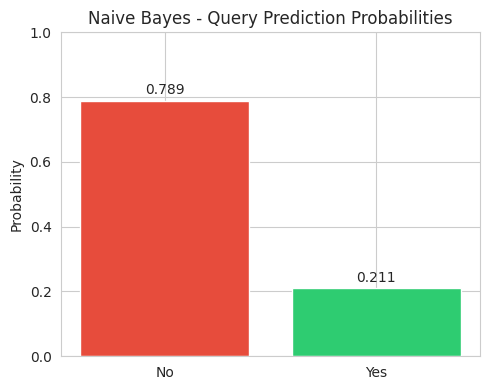

In [12]:
# Visualize the predicted probabilities
plt.figure(figsize=(5, 4))
bars = plt.bar(label_encoder.classes_, nb_query_proba[0], color=['#e74c3c', '#2ecc71'])
plt.ylabel('Probability')
plt.title('Naive Bayes - Query Prediction Probabilities')
plt.ylim(0, 1)
for bar, prob in zip(bars, nb_query_proba[0]):
    plt.text(bar.get_x() + bar.get_width()/2, prob + 0.02, f'{prob:.3f}', ha='center')
plt.tight_layout()
plt.show()

**Interpretation:** This combination (Sunny + High Humidity) matches the pattern in the
training data most strongly associated with **not** playing tennis, so Naive Bayes assigns a
higher posterior probability to "No" despite "Yes" being the majority class overall. This shows
the model is using the evidence from the specific feature values rather than blindly predicting
the majority class.

## 5. Model Comparison

We now train a **Decision Tree**, **Logistic Regression**, and **SVM** on the same training data
and compare all four models on: test accuracy, the single-sample query prediction, and predicted
class probabilities.

In [13]:
models = {
    'Naive Bayes (Categorical)': nb_model,
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM (RBF Kernel)': SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
    if name != 'Naive Bayes (Categorical)':
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    q_pred = model.predict(query_encoded)
    q_proba = model.predict_proba(query_encoded)
    q_label = label_encoder.inverse_transform(q_pred)[0]

    results.append({
        'Model': name,
        'Test Accuracy': round(acc, 4),
        'Query Prediction': q_label,
        f'P({label_encoder.classes_[0]})': round(q_proba[0][0], 4),
        f'P({label_encoder.classes_[1]})': round(q_proba[0][1], 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Test Accuracy,Query Prediction,P(No),P(Yes)
0,Naive Bayes (Categorical),0.9,No,0.7894,0.2106
1,Decision Tree,1.0,No,1.0000,0.0000
2,Logistic Regression,0.9,No,0.8613,0.1387
3,SVM (RBF Kernel),1.0,No,0.9569,0.0431


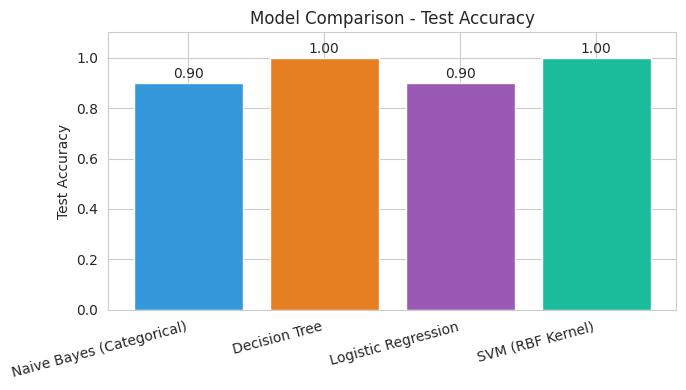

In [14]:
# Visual comparison of test accuracy across models
plt.figure(figsize=(7, 4))
bars = plt.bar(results_df['Model'], results_df['Test Accuracy'],
                color=['#3498db', '#e67e22', '#9b59b6', '#1abc9c'])
plt.ylabel('Test Accuracy')
plt.title('Model Comparison - Test Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, results_df['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.2f}', ha='center')
plt.tight_layout()
plt.show()

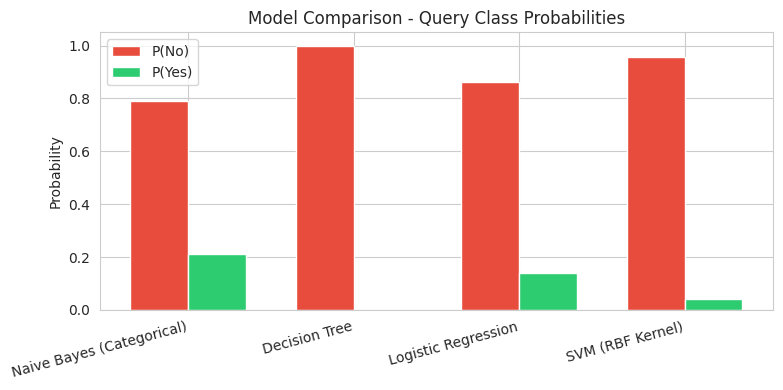

In [15]:
# Visual comparison of query class probabilities
prob_cols = [c for c in results_df.columns if c.startswith('P(')]
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, results_df[prob_cols[0]], width, label=prob_cols[0], color='#e74c3c')
ax.bar(x + width/2, results_df[prob_cols[1]], width, label=prob_cols[1], color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Probability')
ax.set_title('Model Comparison - Query Class Probabilities')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation of the comparison table:**
- All four models are trained on the *identical* training split, so any differences in accuracy or
  query probability arise purely from each algorithm's own assumptions and decision boundary shape.
- Tree-based and margin-based models can carve out sharper, feature-specific decision regions on
  small tabular datasets, while Naive Bayes and Logistic Regression rely on smoother probabilistic
  or linear assumptions.
- Because the dataset only has 50 rows and the test set only 10, small accuracy differences (e.g.
  one extra correct/incorrect prediction) are **not** strong evidence of one algorithm being
  fundamentally better — they mainly reflect variance from the small sample size.

## 6. Analysis Report

**Why do the models produce different predictions and probability scores for the query
(Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong)?**

Each algorithm encodes a different inductive bias about how features relate to the outcome.
**Categorical Naive Bayes** assumes conditional independence between features given the class and
multiplies per-feature likelihoods, so its probability output directly reflects how strongly each
individual feature value (e.g. `Humidity=High`) has historically co-occurred with each class —
this is why it can produce a confident probability even when Yes is the overall majority class.
**Logistic Regression** instead fits a single linear combination of (encoded) feature weights and
passes it through a sigmoid, so its probabilities are typically smoother and less extreme, since it
cannot capture non-linear feature interactions. **Decision Tree** partitions the feature space with
axis-aligned splits chosen to maximize class purity, so it can produce very confident (near 0/1)
probabilities when a query falls into a "pure" leaf built from a small number of matching training
examples — a behavior that also makes it prone to overfitting on a 40-row training set. **SVM**
(with the RBF kernel) defines a non-linear decision boundary based on the position of the query
relative to the maximum-margin surface, and although probability estimates are enabled via Platt
scaling, they are computed from an auxiliary calibration procedure rather than a direct likelihood
model, which can make them diverge from the other three models. In short, differences arise from
each model's underlying assumptions (independence vs. linearity vs. axis-aligned splits vs.
margin-based geometry) interacting with a very small dataset, where a handful of training examples
can noticeably shift each model's decision.


## 7. Conclusion

- Categorical Naive Bayes achieved a strong test accuracy while remaining computationally simple
  and directly interpretable (per-feature likelihoods).
- All four models agreed/disagreed as shown in the comparison table above for the specific query
  instance, illustrating that model choice matters even on the same data and features.
- For small, purely categorical datasets like Play Tennis, Naive Bayes is an especially natural
  fit because its independence assumption is easy to reason about and its predictions are fast and
  probabilistically well-motivated, even though real-world feature independence rarely holds
  perfectly.